In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("health_markers_dataset (1).csv")
print(df.shape)

(25000, 10)


In [2]:
df = df.drop_duplicates().reset_index(drop=True)
print("After dedup:", df.shape)

After dedup: (25000, 10)


In [3]:
df.columns.tolist()

['Blood_glucose',
 'HbA1C',
 'Systolic_BP',
 'Diastolic_BP',
 'LDL',
 'HDL',
 'Triglycerides',
 'Haemoglobin',
 'MCV',
 'Condition']

In [4]:
print(df['Condition'].value_counts())

Condition
Fit                 18000
Diabetes             3052
Hypertension         1757
High_Cholesterol     1323
Anemia                868
Name: count, dtype: int64


In [5]:
noise_level = {
    "Glucose": 0.05,
    "HbA1c": 0.04,
    "Creatinine": 0.06,
    "Hemoglobin": 0.03,
    "LDL": 0.07,
    "HDL": 0.06,
    "Triglycerides": 0.08,
    "Blood_Pressure": 0.05,
    "BMI": 0.04
}

for col, std in noise_level.items():
    if col in df.columns:
        df[col] = df[col] * np.random.normal(
            loc=1.0,
            scale=std,
            size=len(df)
        )

In [6]:
from numpy.random import rand

unique_conditions = df['Condition'].unique()

flip_prob = 0.12  # 12%

for cond in unique_conditions:
    idx = df[df['Condition'] == cond].index
    flip_idx = idx[rand(len(idx)) < flip_prob]

    other_classes = [c for c in unique_conditions if c != cond]
    df.loc[flip_idx, 'Condition'] = np.random.choice(other_classes, size=len(flip_idx))

In [7]:
from sklearn.preprocessing import StandardScaler

feature_cols = df.columns.drop('Condition')

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [8]:
from sklearn.model_selection import train_test_split

X = df[feature_cols].values
y = df['Condition'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [10]:
import numpy as np

print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())

NaNs in X_train: 1183
NaNs in X_val: 275


In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df["Condition"])

LabelEncoder()

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_val)

print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
acc_lr = accuracy_score(y_val, y_pred)

Logistic Regression Accuracy: 0.7608
                  precision    recall  f1-score   support

          Anemia       0.31      0.59      0.40       317
        Diabetes       0.83      0.82      0.83       668
             Fit       0.88      0.79      0.83      3204
High_Cholesterol       0.56      0.64      0.60       361
    Hypertension       0.69      0.69      0.69       450

        accuracy                           0.76      5000
       macro avg       0.65      0.70      0.67      5000
    weighted avg       0.80      0.76      0.77      5000



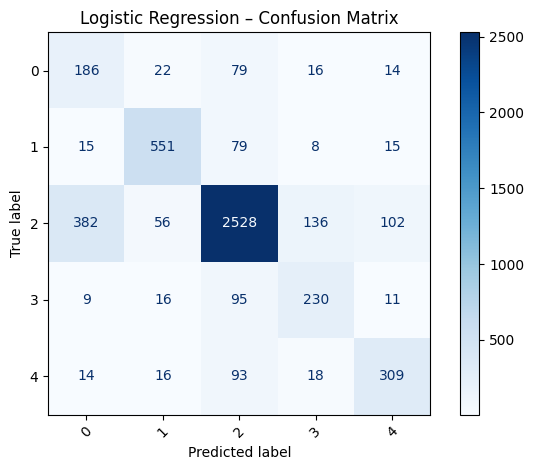

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        batch_size=64,
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    ))
])

mlp_pipeline.fit(X_train, y_train)

y_pred = mlp_pipeline.predict(X_val)

print("MLP Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
acc_mlp = accuracy_score(y_val, y_pred)

MLP Accuracy: 0.8794
                  precision    recall  f1-score   support

          Anemia       0.91      0.53      0.67       317
        Diabetes       0.88      0.82      0.85       668
             Fit       0.88      0.98      0.93      3204
High_Cholesterol       0.86      0.62      0.72       361
    Hypertension       0.86      0.68      0.76       450

        accuracy                           0.88      5000
       macro avg       0.88      0.73      0.79      5000
    weighted avg       0.88      0.88      0.87      5000



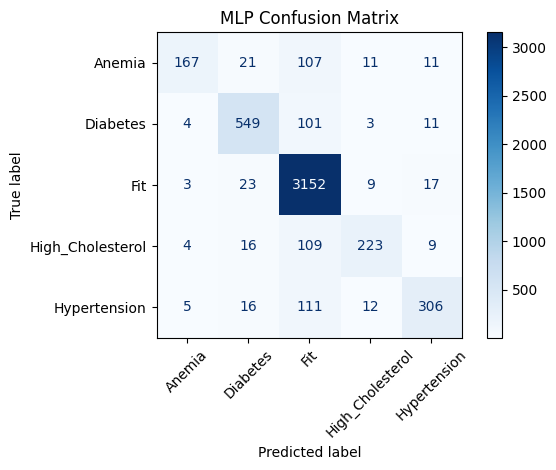

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("MLP Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
X_train_imp = lr_pipeline.named_steps['imputer'].transform(X_train)
X_val_imp = lr_pipeline.named_steps['imputer'].transform(X_val)
X_train_imp.shape, X_val_imp.shape, y_train.shape, y_val.shape

((20000, 9), (5000, 9), (20000,), (5000,))

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim



In [18]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    mask_type="entmax",
    seed=42,
    verbose=1
)

tabnet.fit(
    X_train_imp, y_train,
    eval_set=[(X_val_imp, y_val)],
    eval_metric=["accuracy"],
    max_epochs=100,
    patience=20,
    batch_size=256,
    virtual_batch_size=64,
    num_workers=0,
    drop_last=False
)

c:\Python312\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.33536 | val_0_accuracy: 0.7624  |  0:00:07s
epoch 1  | loss: 0.81499 | val_0_accuracy: 0.8316  |  0:00:14s
epoch 2  | loss: 0.69679 | val_0_accuracy: 0.8504  |  0:00:20s
epoch 3  | loss: 0.65341 | val_0_accuracy: 0.8608  |  0:00:24s
epoch 4  | loss: 0.63756 | val_0_accuracy: 0.8668  |  0:00:29s
epoch 5  | loss: 0.61842 | val_0_accuracy: 0.8718  |  0:00:33s
epoch 6  | loss: 0.598   | val_0_accuracy: 0.872   |  0:00:38s
epoch 7  | loss: 0.5891  | val_0_accuracy: 0.8754  |  0:00:43s
epoch 8  | loss: 0.57869 | val_0_accuracy: 0.8748  |  0:00:48s
epoch 9  | loss: 0.57787 | val_0_accuracy: 0.8762  |  0:00:52s
epoch 10 | loss: 0.57348 | val_0_accuracy: 0.8768  |  0:00:57s
epoch 11 | loss: 0.57008 | val_0_accuracy: 0.8776  |  0:01:01s
epoch 12 | loss: 0.56785 | val_0_accuracy: 0.8772  |  0:01:06s
epoch 13 | loss: 0.56673 | val_0_accuracy: 0.878   |  0:01:10s
epoch 14 | loss: 0.56341 | val_0_accuracy: 0.8782  |  0:01:15s
epoch 15 | loss: 0.56084 | val_0_accuracy: 0.878   |  0

c:\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [19]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_tab = tabnet.predict(X_val_imp)

print("TabNet Accuracy:", accuracy_score(y_val, y_pred_tab))
print(classification_report(y_val, y_pred_tab))
acc_tabnet = accuracy_score(y_val, y_pred_tab) 

TabNet Accuracy: 0.8796
                  precision    recall  f1-score   support

          Anemia       0.91      0.53      0.67       317
        Diabetes       0.88      0.82      0.85       668
             Fit       0.88      0.98      0.93      3204
High_Cholesterol       0.86      0.62      0.72       361
    Hypertension       0.86      0.68      0.76       450

        accuracy                           0.88      5000
       macro avg       0.88      0.73      0.79      5000
    weighted avg       0.88      0.88      0.87      5000



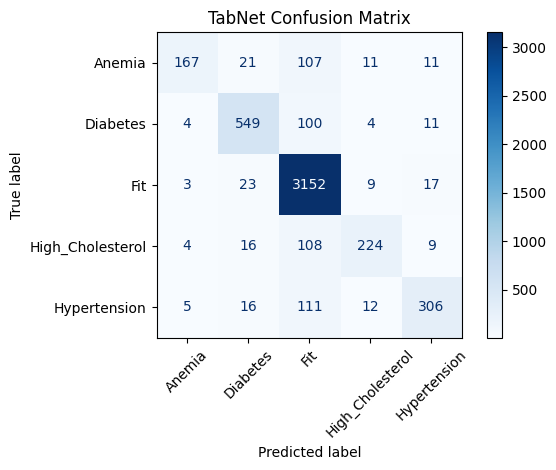

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred_tab)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("TabNet Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
class FeatureTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_features, d_token))
        self.bias = nn.Parameter(torch.zeros(n_features, d_token))

    def forward(self, x):
        # x: (batch, n_features)
        return x.unsqueeze(-1) * self.weight + self.bias

In [22]:
class TransformerBlock(nn.Module):
    def __init__(self, d_token, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=d_token,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_token * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_token * 4, d_token)
        )
        self.norm1 = nn.LayerNorm(d_token)
        self.norm2 = nn.LayerNorm(d_token)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

In [23]:
class FTTransformer(nn.Module):
    def __init__(self, n_features, n_classes, d_token=64, depth=3, n_heads=4, dropout=0.4):
        super().__init__()

        self.tokenizer = FeatureTokenizer(n_features, d_token)

        self.blocks = nn.Sequential(*[
            TransformerBlock(d_token, n_heads, dropout)
            for _ in range(depth)
        ])

        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, n_classes)
        )

    def forward(self, x):
        # x: (batch, n_features)
        x = self.tokenizer(x)      # (batch, n_features, d_token)
        x = self.blocks(x)
        x = x.mean(dim=1)          # global pooling
        return self.head(x)

In [24]:
import torch.optim as optim

In [25]:
print(type(y_train[0]), y_train[:5])

<class 'str'> ['Fit' 'Hypertension' 'Fit' 'Fit' 'Fit']


In [26]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)

In [27]:
print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

Label mapping:
Anemia -> 0
Diabetes -> 1
Fit -> 2
High_Cholesterol -> 3
Hypertension -> 4


In [28]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

Xtr = torch.tensor(X_train_imp, dtype=torch.float32).to(device)
ytr = torch.tensor(y_train_enc, dtype=torch.long).to(device)

Xva = torch.tensor(X_val_imp, dtype=torch.float32).to(device)
yva = torch.tensor(y_val_enc, dtype=torch.long).to(device)

In [29]:


model = FTTransformer(
    n_features=X_train_imp.shape[1],
    n_classes=len(set(y_train_enc)),
    d_token=60,     # DO NOT increase
    depth=3,        # DO NOT increase
    n_heads=4,
    dropout=0.4
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_loss = float("inf")
patience = 5
wait = 0

for epoch in range(100):
    model.train()
    optimizer.zero_grad()

    logits = model(Xtr)
    loss = criterion(logits, ytr)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(Xva)
        val_loss = criterion(val_logits, yva)

    print(f"Epoch {epoch:03d} | Train {loss:.4f} | Val {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping")
            break

Epoch 000 | Train 1.9098 | Val 1.0973
Epoch 001 | Train 1.1421 | Val 0.9737
Epoch 002 | Train 1.0327 | Val 0.9477
Epoch 003 | Train 1.0202 | Val 0.8891
Epoch 004 | Train 0.9678 | Val 0.8278
Epoch 005 | Train 0.9046 | Val 0.7898
Epoch 006 | Train 0.8570 | Val 0.7719
Epoch 007 | Train 0.8246 | Val 0.7580
Epoch 008 | Train 0.7993 | Val 0.7409
Epoch 009 | Train 0.7708 | Val 0.7219
Epoch 010 | Train 0.7467 | Val 0.7037
Epoch 011 | Train 0.7248 | Val 0.6873
Epoch 012 | Train 0.7067 | Val 0.6729
Epoch 013 | Train 0.6940 | Val 0.6608
Epoch 014 | Train 0.6822 | Val 0.6509
Epoch 015 | Train 0.6738 | Val 0.6431
Epoch 016 | Train 0.6633 | Val 0.6372
Epoch 017 | Train 0.6577 | Val 0.6328
Epoch 018 | Train 0.6512 | Val 0.6296
Epoch 019 | Train 0.6450 | Val 0.6272
Epoch 020 | Train 0.6408 | Val 0.6252
Epoch 021 | Train 0.6354 | Val 0.6234
Epoch 022 | Train 0.6335 | Val 0.6214
Epoch 023 | Train 0.6271 | Val 0.6189
Epoch 024 | Train 0.6236 | Val 0.6156
Epoch 025 | Train 0.6192 | Val 0.6115
Epoch 026 | 

In [30]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()
with torch.no_grad():
    y_pred_enc = torch.argmax(model(Xva), dim=1).cpu().numpy()

y_pred = label_encoder.inverse_transform(y_pred_enc)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
acc_ft = accuracy_score(y_val, y_pred)

Accuracy: 0.8796
                  precision    recall  f1-score   support

          Anemia       0.91      0.53      0.67       317
        Diabetes       0.88      0.82      0.85       668
             Fit       0.88      0.98      0.93      3204
High_Cholesterol       0.86      0.62      0.72       361
    Hypertension       0.86      0.68      0.76       450

        accuracy                           0.88      5000
       macro avg       0.88      0.73      0.79      5000
    weighted avg       0.88      0.88      0.87      5000



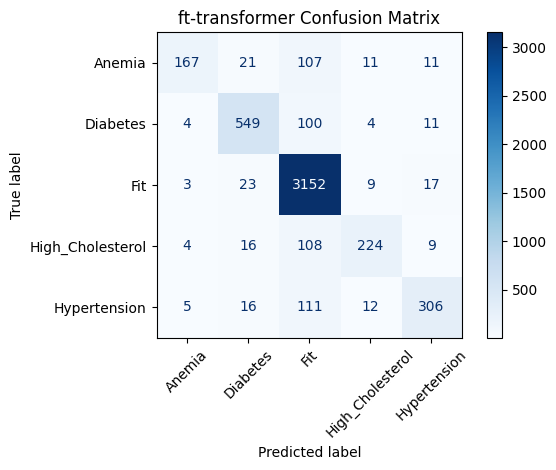

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("ft-transformer Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_val_enc,        # encoded ground truth
    y_pred_enc,       # encoded predictions
    average="macro"
)

print("Macro-F1:", macro_f1)

Macro-F1: 0.7858636699929484


In [33]:

print(np.bincount(y_train_enc))

[ 1267  2672 12818  1442  1801]


In [34]:
X_train_imp, X_val_imp   # imputed + scaled
y_train_enc, y_val_enc 

import numpy as np

num_classes = len(np.unique(y_train_enc))
# integer-encoded labels
              # len(np.unique(y_train_enc))

In [35]:
import xgboost as xgb
from sklearn.metrics import f1_score, accuracy_score, classification_report

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42
)

xgb_clf.fit(
    X_train_imp, y_train_enc,          # or X_train_sm, y_train_sm
    eval_set=[(X_val_imp, y_val_enc)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_class=5, num_parallel_tree=None, ...)

In [36]:
y_pred_xgb = xgb_clf.predict(X_val_imp)

print("XGBoost Accuracy:", accuracy_score(y_val_enc, y_pred_xgb))
print("XGBoost Macro-F1:", f1_score(y_val_enc, y_pred_xgb, average="macro"))
print(classification_report(y_val_enc, y_pred_xgb))
acc_xgb = accuracy_score(y_val_enc, y_pred_xgb)

XGBoost Accuracy: 0.8794
XGBoost Macro-F1: 0.7847396925151628
              precision    recall  f1-score   support

           0       0.91      0.52      0.66       317
           1       0.88      0.82      0.85       668
           2       0.88      0.98      0.93      3204
           3       0.86      0.62      0.72       361
           4       0.86      0.68      0.76       450

    accuracy                           0.88      5000
   macro avg       0.88      0.73      0.78      5000
weighted avg       0.88      0.88      0.87      5000



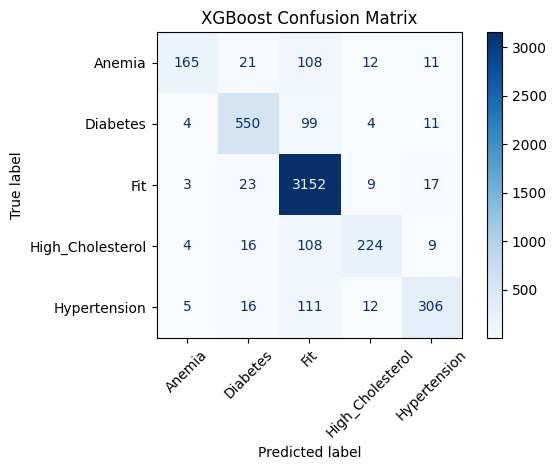

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val_enc, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

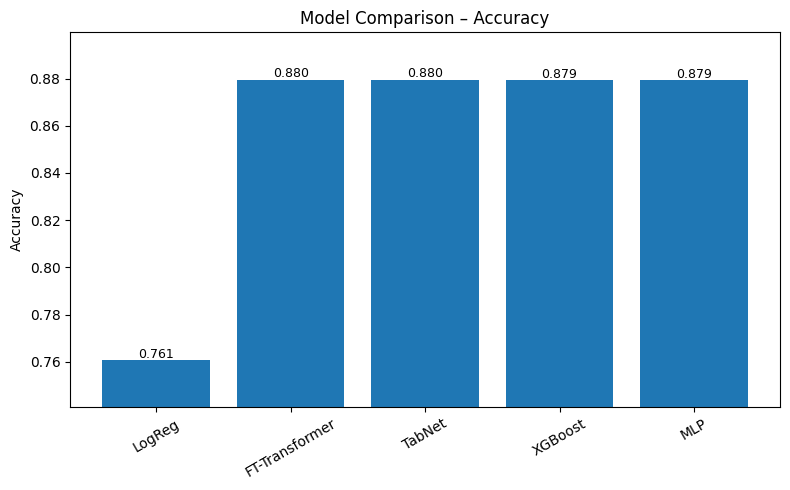

In [38]:
import matplotlib.pyplot as plt

models = [
    "LogReg",
    "FT-Transformer",
    "TabNet",
    "XGBoost",
   'MLP' 
]

accuracies = [
    acc_lr,
    acc_ft,
    acc_tabnet,
    acc_xgb,
    acc_mlp
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison – Accuracy")

plt.xticks(rotation=30)

# 🔥 ZOOMED Y-AXIS (KEY FIX)
plt.ylim(min(accuracies) - 0.02, max(accuracies) + 0.02)

# Show values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_val)
n_classes = y_test_bin.shape[1]

lb = LabelBinarizer()
# use the validation set here – there is no `y_test` variable
y_test_bin = lb.fit_transform(y_val)
n_classes = y_test_bin.shape[1]
n_classes = y_test_bin.shape[1]

In [40]:
y_score_xgb = xgb_clf.predict_proba(X_val_imp)

In [41]:
y_score_tabnet = tabnet.predict_proba(X_val_imp)

In [42]:
# use the fitted TabNet instance and the data you actually have
# (validation set used as test – there’s no X_test variable)
y_score_tabnet = tabnet.predict_proba(X_val_imp)

In [43]:
import torch
from sklearn.metrics import roc_curve, auc

ft_model = model
ft_model.eval()

with torch.no_grad():
    y_score_ft = torch.softmax(ft_model(Xva), dim=1).cpu().numpy()

with torch.no_grad():
    pass

In [44]:
fpr_xgb, tpr_xgb, roc_auc_xgb = {}, {}, {}
fpr_tab, tpr_tab, roc_auc_tab = {}, {}, {}
fpr_ft, tpr_ft, roc_auc_ft = {}, {}, {}

for i in range(n_classes):

    # XGBoost
    fpr_xgb[i], tpr_xgb[i], _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc_xgb[i] = auc(fpr_xgb[i], tpr_xgb[i])

    # TabNet
    fpr_tab[i], tpr_tab[i], _ = roc_curve(y_test_bin[:, i], y_score_tabnet[:, i])
    roc_auc_tab[i] = auc(fpr_tab[i], tpr_tab[i])

    # FT Transformer
    fpr_ft[i], tpr_ft[i], _ = roc_curve(y_test_bin[:, i], y_score_ft[:, i])
    roc_auc_ft[i] = auc(fpr_ft[i], tpr_ft[i])

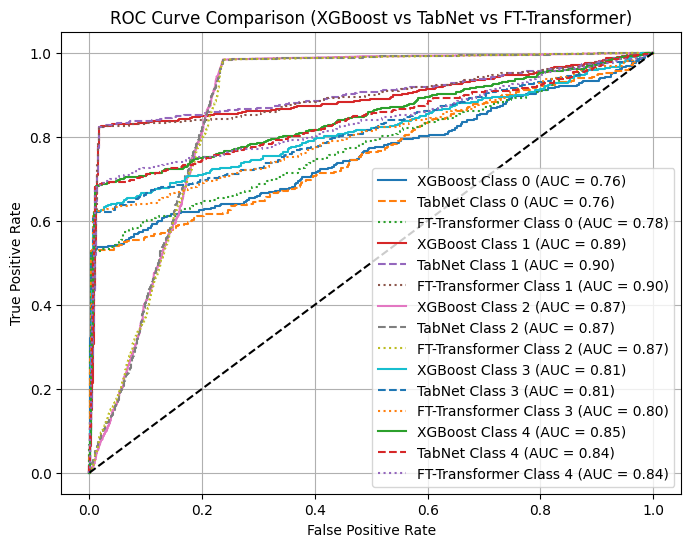

In [45]:
plt.figure(figsize=(8,6))

for i in range(n_classes):

    plt.plot(fpr_xgb[i], tpr_xgb[i],
             label=f'XGBoost Class {i} (AUC = {roc_auc_xgb[i]:.2f})')

    plt.plot(fpr_tab[i], tpr_tab[i],
             linestyle='--',
             label=f'TabNet Class {i} (AUC = {roc_auc_tab[i]:.2f})')

    plt.plot(fpr_ft[i], tpr_ft[i],
             linestyle=':',
             label=f'FT-Transformer Class {i} (AUC = {roc_auc_ft[i]:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (XGBoost vs TabNet vs FT-Transformer)")
plt.legend()
plt.grid(True)

plt.show()

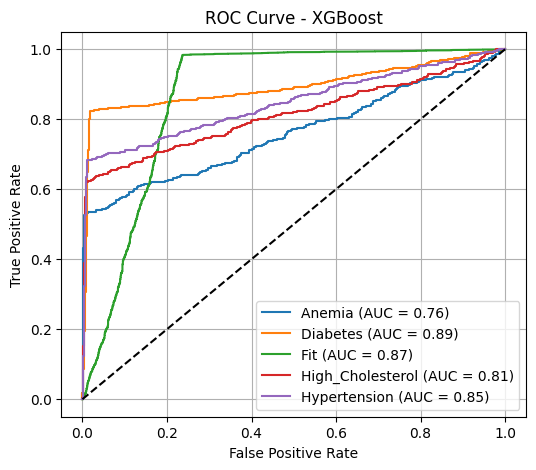

In [46]:

y_score_xgb = xgb_clf.predict_proba(X_val_imp)

plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")

plt.legend()
plt.grid()
plt.show()

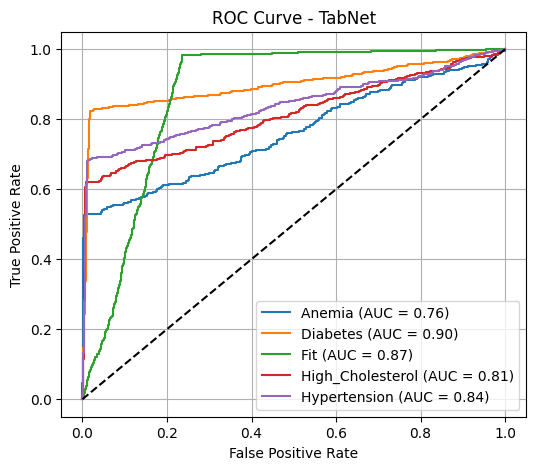

In [47]:
y_score_tabnet = tabnet.predict_proba(X_val_imp)

plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_tabnet[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TabNet")

plt.legend()
plt.grid()

plt.show()
plt.show()

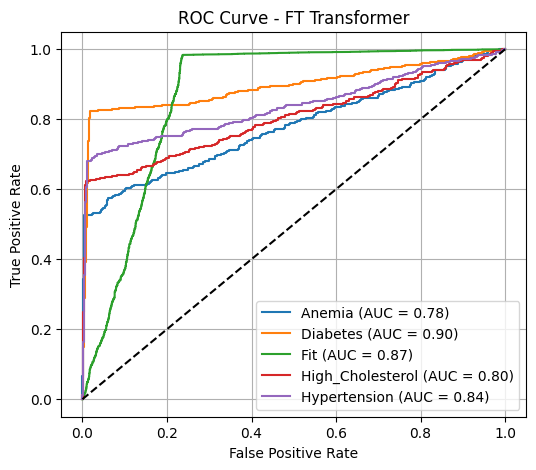

In [48]:
import torch
from sklearn.metrics import roc_curve, auc

ft_model = model
ft_model.eval()

with torch.no_grad():
    y_score_ft = torch.softmax(ft_model(Xva), dim=1).cpu().numpy()

with torch.no_grad():
    pass
plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_ft[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - FT Transformer")

plt.legend()
plt.grid()
plt.show()

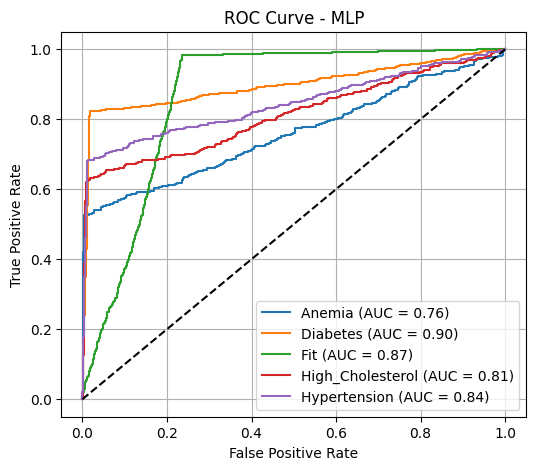

In [49]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

# Convert labels to binary format

n_classes = y_test_bin.shape[1]

# Get probability predictions
y_score_mlp = mlp_pipeline.predict_proba(X_val_imp)

plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_mlp[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")

plt.legend()
plt.grid()
plt.show()

In [51]:
import joblib
joblib.dump(tabnet, "tabnet_model.pkl")

['tabnet_model.pkl']